In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.io import loadmat

In [3]:
data = loadmat("stack.mat")

In [4]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'numframes', 'frame001', 'frame002', 'frame003', 'frame004', 'frame005', 'frame006', 'frame007', 'frame008', 'frame009', 'frame010', 'frame011', 'frame012', 'frame013', 'frame014', 'frame015', 'frame016', 'frame017', 'frame018', 'frame019', 'frame020', 'frame021', 'frame022', 'frame023', 'frame024', 'frame025', 'frame026', 'frame027', 'frame028', 'frame029', 'frame030', 'frame031', 'frame032', 'frame033', 'frame034', 'frame035', 'frame036', 'frame037', 'frame038', 'frame039', 'frame040', 'frame041', 'frame042', 'frame043', 'frame044', 'frame045', 'frame046', 'frame047', 'frame048', 'frame049', 'frame050', 'frame051', 'frame052', 'frame053', 'frame054', 'frame055', 'frame056', 'frame057', 'frame058', 'frame059', 'frame060', 'frame061', 'frame062', 'frame063', 'frame064', 'frame065', 'frame066', 'frame067', 'frame068', 'frame069', 'frame070', 'frame071', 'frame072', 'frame073', 'frame074', 'frame075', 'frame076', 'frame077', 'frame07

In [5]:
numframes = int(data["numframes"][0][0])
print("No of frames : ", numframes)

No of frames :  100


In [6]:
frames = []

In [7]:
for i in range(1, numframes + 1):
  key = f'frame{i:03d}'
  frame = data[key]
  frame = frame.astype(np.float64)
  frames.append(frame)

In [8]:
frames

[array([[56., 56., 57., ..., 52., 51., 51.],
        [56., 56., 57., ..., 52., 51., 51.],
        [57., 57., 58., ..., 53., 52., 52.],
        ...,
        [52., 52., 53., ..., 58., 57., 57.],
        [51., 51., 52., ..., 58., 57., 57.],
        [51., 51., 52., ..., 57., 57., 56.]]),
 array([[55., 55., 56., ..., 51., 50., 50.],
        [55., 56., 57., ..., 51., 51., 50.],
        [56., 57., 58., ..., 52., 51., 51.],
        ...,
        [52., 52., 52., ..., 58., 57., 57.],
        [51., 51., 52., ..., 57., 57., 56.],
        [51., 51., 51., ..., 57., 56., 56.]]),
 array([[55., 55., 56., ..., 51., 50., 50.],
        [55., 56., 57., ..., 51., 50., 50.],
        [56., 57., 58., ..., 52., 51., 51.],
        ...,
        [52., 52., 52., ..., 59., 58., 57.],
        [51., 51., 52., ..., 58., 57., 57.],
        [51., 51., 51., ..., 58., 57., 57.]]),
 array([[55., 56., 57., ..., 51., 51., 50.],
        [56., 56., 57., ..., 52., 51., 51.],
        [57., 57., 58., ..., 53., 52., 51.],
        ..

In [9]:
frames = np.array(frames)

In [10]:
frames

array([[[ 56.,  56.,  57., ...,  52.,  51.,  51.],
        [ 56.,  56.,  57., ...,  52.,  51.,  51.],
        [ 57.,  57.,  58., ...,  53.,  52.,  52.],
        ...,
        [ 52.,  52.,  53., ...,  58.,  57.,  57.],
        [ 51.,  51.,  52., ...,  58.,  57.,  57.],
        [ 51.,  51.,  52., ...,  57.,  57.,  56.]],

       [[ 55.,  55.,  56., ...,  51.,  50.,  50.],
        [ 55.,  56.,  57., ...,  51.,  51.,  50.],
        [ 56.,  57.,  58., ...,  52.,  51.,  51.],
        ...,
        [ 52.,  52.,  52., ...,  58.,  57.,  57.],
        [ 51.,  51.,  52., ...,  57.,  57.,  56.],
        [ 51.,  51.,  51., ...,  57.,  56.,  56.]],

       [[ 55.,  55.,  56., ...,  51.,  50.,  50.],
        [ 55.,  56.,  57., ...,  51.,  50.,  50.],
        [ 56.,  57.,  58., ...,  52.,  51.,  51.],
        ...,
        [ 52.,  52.,  52., ...,  59.,  58.,  57.],
        [ 51.,  51.,  52., ...,  58.,  57.,  57.],
        [ 51.,  51.,  51., ...,  58.,  57.,  57.]],

       ...,

       [[227.,   9.,  22

In [11]:
print("Frames shape : ", frames.shape)

Frames shape :  (100, 115, 115)


In [12]:
frames = np.transpose(frames, (1,2,0))

In [13]:
print("Frames shape : ", frames.shape)

Frames shape :  (115, 115, 100)


In [14]:
H, W, N = frames.shape

In [15]:
print(H, W, N)

115 115 100


In [16]:
def modified_laplacian(image):
  H, W = image.shape
  ML = np.zeros((H,W))

  for x in range(1, H-1):
    for y in range(1, W-1):

      dx = abs(image[x+1,y] - 2*image[x,y] + image[x-1, y])
      dy = abs(image[x,y+1] - 2*image[x,y] + image[x, y-1])

      ML[x,y] = dx + dy

  return ML


In [17]:
def SML(ML, q):

  H, W = ML.shape

  sml = np.zeros((H,W))

  for x in range(q, H-q):
    for y in range(q, W-q):

      window = ML[x-q:x+q+1, y-q:y+q+1]

      sml[x,y] = np.sum(window)

  return sml


In [18]:
def compute_focus_volume(frames, q):

    H,W,N = frames.shape

    focus_volume = np.zeros((H,W,N))

    for k in range(N):

        image = frames[:,:,k]

        ML = modified_laplacian(image)

        focus_map = SML(ML, q)

        focus_volume[:,:,k] = focus_map

        print("Processed frame",k)

    return focus_volume

In [19]:
def compute_depth(focus_volume, delta_d):

    depth_index = np.argmax(focus_volume, axis=2)

    depth = depth_index * delta_d

    return depth

In [20]:
def plot_depth(depth):

    H,W = depth.shape

    X = np.arange(W)
    Y = np.arange(H)

    X,Y = np.meshgrid(X,Y)

    fig = plt.figure()

    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X,Y,depth,cmap='viridis')

    ax.set_title("3D Depth Map")

    plt.show()

Running for q = 0
Processed frame 0
Processed frame 1
Processed frame 2
Processed frame 3
Processed frame 4
Processed frame 5
Processed frame 6
Processed frame 7
Processed frame 8
Processed frame 9
Processed frame 10
Processed frame 11
Processed frame 12
Processed frame 13
Processed frame 14
Processed frame 15
Processed frame 16
Processed frame 17
Processed frame 18
Processed frame 19
Processed frame 20
Processed frame 21
Processed frame 22
Processed frame 23
Processed frame 24
Processed frame 25
Processed frame 26
Processed frame 27
Processed frame 28
Processed frame 29
Processed frame 30
Processed frame 31
Processed frame 32
Processed frame 33
Processed frame 34
Processed frame 35
Processed frame 36
Processed frame 37
Processed frame 38
Processed frame 39
Processed frame 40
Processed frame 41
Processed frame 42
Processed frame 43
Processed frame 44
Processed frame 45
Processed frame 46
Processed frame 47
Processed frame 48
Processed frame 49
Processed frame 50
Processed frame 51
Proc

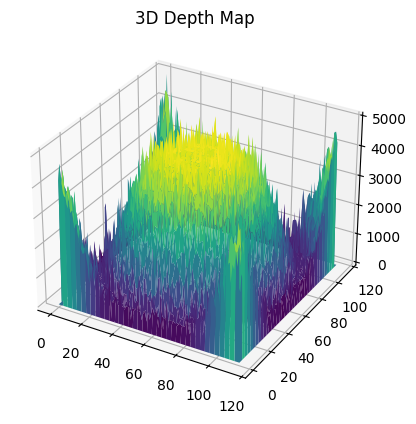

Running for q = 1
Processed frame 0
Processed frame 1
Processed frame 2
Processed frame 3
Processed frame 4
Processed frame 5
Processed frame 6
Processed frame 7
Processed frame 8
Processed frame 9
Processed frame 10
Processed frame 11
Processed frame 12
Processed frame 13
Processed frame 14
Processed frame 15
Processed frame 16
Processed frame 17
Processed frame 18
Processed frame 19
Processed frame 20
Processed frame 21
Processed frame 22
Processed frame 23
Processed frame 24
Processed frame 25
Processed frame 26
Processed frame 27
Processed frame 28
Processed frame 29
Processed frame 30
Processed frame 31
Processed frame 32
Processed frame 33
Processed frame 34
Processed frame 35
Processed frame 36
Processed frame 37
Processed frame 38
Processed frame 39
Processed frame 40
Processed frame 41
Processed frame 42
Processed frame 43
Processed frame 44
Processed frame 45
Processed frame 46
Processed frame 47
Processed frame 48
Processed frame 49
Processed frame 50
Processed frame 51
Proc

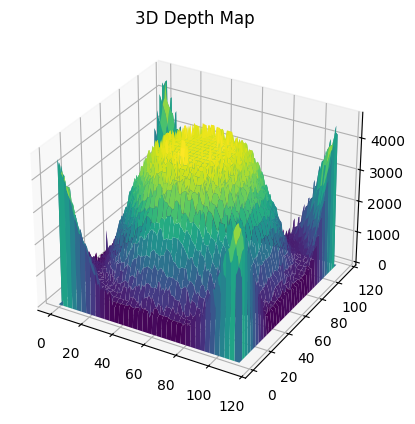

Running for q = 2
Processed frame 0
Processed frame 1
Processed frame 2
Processed frame 3
Processed frame 4
Processed frame 5
Processed frame 6
Processed frame 7
Processed frame 8
Processed frame 9
Processed frame 10
Processed frame 11
Processed frame 12
Processed frame 13
Processed frame 14
Processed frame 15
Processed frame 16
Processed frame 17
Processed frame 18
Processed frame 19
Processed frame 20
Processed frame 21
Processed frame 22
Processed frame 23
Processed frame 24
Processed frame 25
Processed frame 26
Processed frame 27
Processed frame 28
Processed frame 29
Processed frame 30
Processed frame 31
Processed frame 32
Processed frame 33
Processed frame 34
Processed frame 35
Processed frame 36
Processed frame 37
Processed frame 38
Processed frame 39
Processed frame 40
Processed frame 41
Processed frame 42
Processed frame 43
Processed frame 44
Processed frame 45
Processed frame 46
Processed frame 47
Processed frame 48
Processed frame 49
Processed frame 50
Processed frame 51
Proc

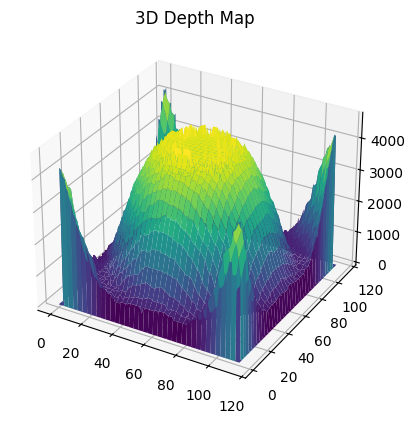

In [21]:
delta_d = 50.50

for q in [0,1,2]:

    print("Running for q =",q)

    focus_volume = compute_focus_volume(frames,q)

    depth = compute_depth(focus_volume,delta_d)

    plot_depth(depth)